## EN3160 Assignment 01 -  Intensity Transformations and Neighborhood Filtering

### 230636K  Tharushika G.K.E.

### Link to GitHub respository - https://github.com/ErandiTharushika/A01-Intensity-Transformations-and-Spatial-Filtering

### Question 1

Implementing the given intensity transformation

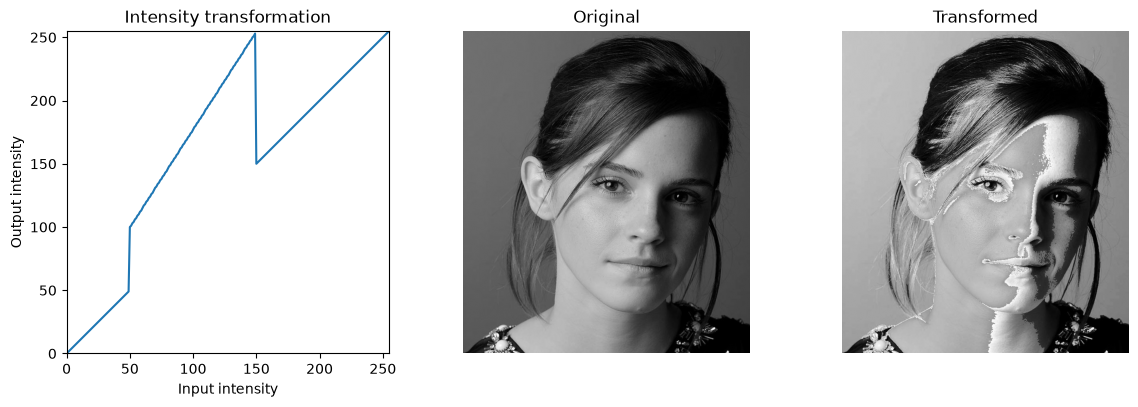

In [99]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
    bp = np.array(breakpoints, dtype=float)
    xs, ys = bp[:, 0], bp[:, 1]
    lut = np.zeros(256, dtype='uint8')
    for i in range(len(bp) - 1):
        x0, y0 = xs[i], ys[i]
        x1, y1 = xs[i + 1], ys[i + 1]
        x0i, x1i = int(x0), int(x1)
        if x1i == x0i: 
            continue
        seg = np.linspace(y0, y1, x1i - x0i + 1)
        if i < len(bp) - 2: 
            lut[x0i:x1i] = seg[:-1].astype('uint8')
        else:                  
            lut[x0i:x1i + 1] = seg.astype('uint8')

    transformed = cv.LUT(im, lut)
    return transformed, lut

breakpoints = [(0, 0), (50, 50), (50, 100), (150, 255), (150,150), (255, 255)]
img_orig = cv.imread('images/q1.jpeg', cv.IMREAD_GRAYSCALE)
img_transformed, lut = intensity_transform(img_orig, breakpoints)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].plot(lut)
axes[0].set_xlabel('Input intensity')
axes[0].set_ylabel('Output intensity')
axes[0].set_xlim(0, 255)
axes[0].set_ylim(0, 255)
axes[0].set_aspect('equal')
axes[0].set_title('Intensity transformation')

axes[1].imshow(img_orig, cmap='gray')
axes[1].set_title('Original')
axes[1].axis('off')

axes[2].imshow(img_transformed, cmap='gray')
axes[2].set_title('Transformed')
axes[2].axis('off')

plt.tight_layout()
plt.show()

According to the intensity transformation, pixels from 0–50 and 150-255 remain unchanged, while middle values are shifted upwards. This leads to the rise of high contrast regions in the output image.

Experimenting with different breakpoints

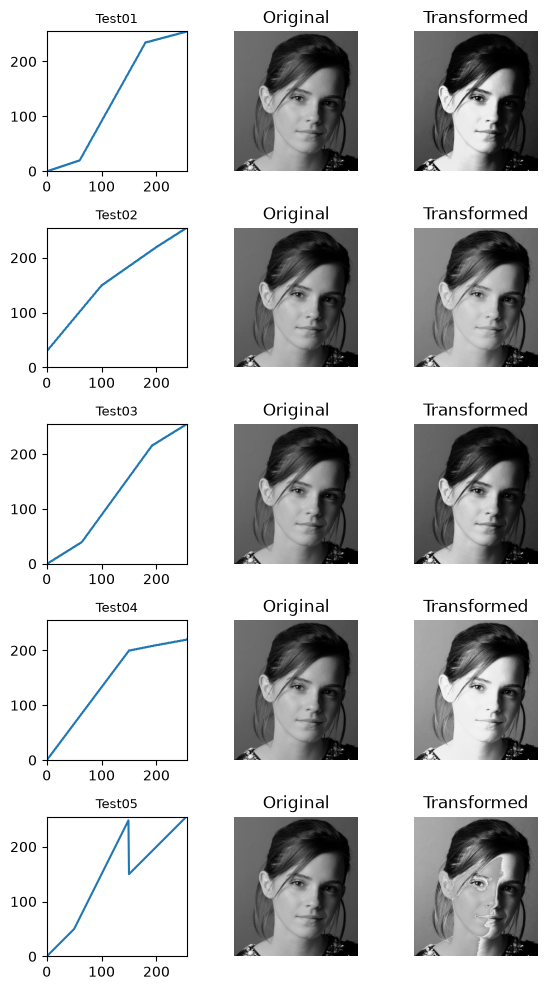

In [100]:
test_breakpoints = {
    "Test01": [(0, 0), (60, 20), (180, 235), (255, 255)],
    "Test02": [(0, 30), (100, 150), (200, 220), (255, 255)],
    "Test03": [(0, 0), (64, 40), (128, 128), (192, 216), (255, 255)],
    "Test04": [(0, 0), (150, 200), (200, 210), (255, 220)],
    "Test05": [(0, 0), (50, 50), (150, 250), (150, 150), (255, 255)],
}
fig, axes = plt.subplots(len(test_breakpoints), 3, figsize=(6, 2 * len(test_breakpoints)))

for row, (label, bp) in enumerate(test_breakpoints.items()):
    transformed, lut = intensity_transform(img_orig, bp)
    
    axes[row, 0].plot(lut)
    axes[row, 0].set_xlim(0, 255); axes[row, 0].set_ylim(0, 255)
    axes[row, 0].set_aspect('equal')
    axes[row, 0].set_title(label, fontsize=9)

    axes[row, 1].imshow(img_orig, cmap='gray')
    axes[row, 1].set_title('Original'); axes[row, 1].axis('off')

    axes[row, 2].imshow(transformed, cmap='gray')
    axes[row, 2].set_title('Transformed'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

### Question 2

Observing the histogram of the image

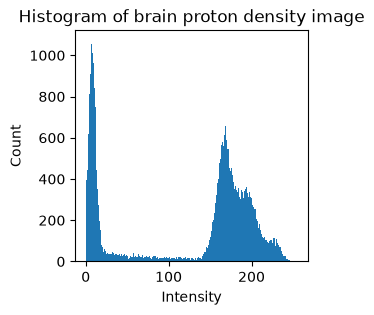

In [137]:
img_orig = cv.imread('images/q2.jpeg', cv.IMREAD_GRAYSCALE)
plt.figure(figsize=(3, 3))
plt.hist(img_orig.ravel(), bins=256, range=(0, 255))
plt.title('Histogram of brain proton density image')
plt.xlabel('Intensity')
plt.ylabel('Count')
plt.show()

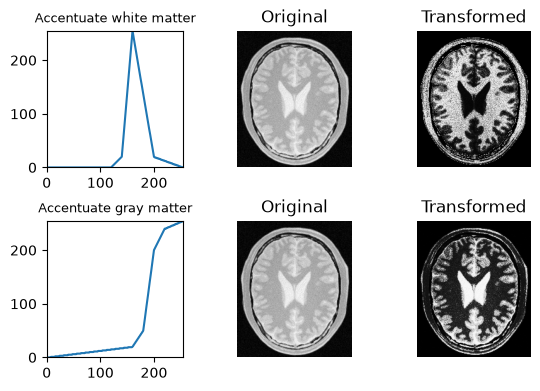

In [138]:
transforms = {
    "Accentuate white matter": [(0, 0), (120, 0), (140, 20), (160, 255), (200, 20), (255, 0)],
    "Accentuate gray matter": [(0, 0), (160, 20), (180, 50), (200, 200), (220, 240), (255, 255)]
}
fig, axes = plt.subplots(len(transforms), 3, figsize=(6, 2 * len(transforms)))

for row, (label, bp) in enumerate(transforms.items()):
    transformed, lut = intensity_transform(img_orig, bp)

    axes[row, 0].plot(lut)
    axes[row, 0].set_xlim(0, 255); axes[row, 0].set_ylim(0, 255)
    axes[row, 0].set_aspect('equal')
    axes[row, 0].set_title(label, fontsize=9)

    axes[row, 1].imshow(img_orig, cmap='gray')
    axes[row, 1].set_title('Original'); axes[row, 1].axis('off')

    axes[row, 2].imshow(transformed, cmap='gray')
    axes[row, 2].set_title('Transformed'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

The above value ranges are chosen by looking at the histogram of the original image.

### Question 3

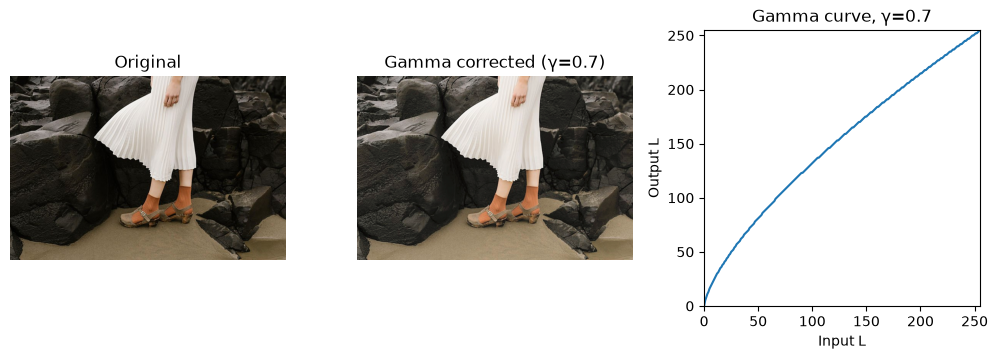

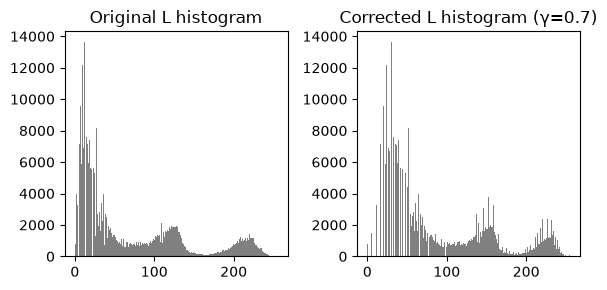

In [ ]:
img_bgr = cv.imread('images/q3.jpeg', cv.IMREAD_COLOR)
img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)

L, a, b = cv.split(img_lab)
gamma = 0.7
lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype='uint8')
L_corrected = cv.LUT(L, lut)

img_lab_corrected = cv.merge([L_corrected, a, b])
img_bgr_corrected = cv.cvtColor(img_lab_corrected, cv.COLOR_LAB2BGR)

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(img_bgr_corrected, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Gamma corrected (γ={gamma})')
axes[1].axis('off')

axes[2].plot(lut)
axes[2].set_xlim(0, 255)
axes[2].set_ylim(0, 255)
axes[2].set_box_aspect(1)
axes[2].set_xlabel('Input L')
axes[2].set_ylabel('Output L')
axes[2].set_title(f'Gamma curve, γ={gamma}')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].hist(L.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original L histogram')
axes[1].hist(L_corrected.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title(f'Corrected L histogram (γ={gamma})')
plt.tight_layout()
plt.show()

With γ=0.7, the correction lifts the dark tones more than the bright ones. So the rocks have got more texture without being solid black and the bright values stay almost same, but a little brighter. We can see this from the histogram too.

### Question 4

#### (a) Splitting the image into hue, saturation, and value planes

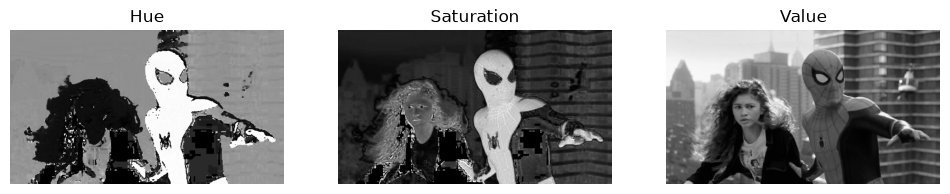

In [149]:
img_bgr = cv.imread('images/q4.jpeg', cv.IMREAD_COLOR)
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
h, s, v = cv.split(img_hsv)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(h, cmap='gray'); axes[0].set_title('Hue'); axes[0].axis('off')
axes[1].imshow(s, cmap='gray'); axes[1].set_title('Saturation'); axes[1].axis('off')
axes[2].imshow(v, cmap='gray'); axes[2].set_title('Value'); axes[2].axis('off')
plt.show()

#### (b) Applying the aforementioned intensity transformation to the saturation plane

In [150]:
def vibrance_lut(a, sigma=70):
    x = np.arange(256, dtype=np.float64)
    f = x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2))
    f = np.clip(f, 0, 255)
    return f.astype('uint8')

a = 0.6 
sigma = 70
lut = vibrance_lut(a, sigma)
s_vibrant = cv.LUT(s, lut)

#### (c) Adjust a and report the value

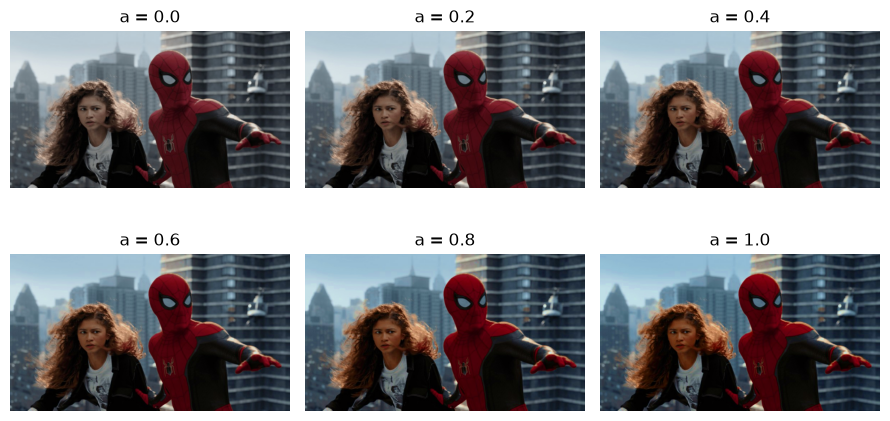

In [155]:
fig, axes = plt.subplots(2, 3, figsize=(9, 5))
a_values = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

for ax, a_test in zip(axes.ravel(), a_values):
    lut_test = vibrance_lut(a_test, sigma)
    s_test = cv.LUT(s, lut_test)
    hsv_test = cv.merge([h, s_test, v])
    bgr_test = cv.cvtColor(hsv_test, cv.COLOR_HSV2BGR)
    ax.imshow(cv.cvtColor(bgr_test, cv.COLOR_BGR2RGB))
    ax.set_title(f'a = {a_test}')
    ax.axis('off')

axes.ravel()[-1].axis('off') 
plt.tight_layout()
plt.show()

a = 0.6 
lut = vibrance_lut(a, sigma)
s_vibrant = cv.LUT(s, lut)

After testing the image on a range of values as implemented above, a=0.6 is chosen as the best value.

#### (d) Recombining the three planes

In [107]:
img_hsv_vibrant = cv.merge([h, s_vibrant, v])
img_bgr_vibrant = cv.cvtColor(img_hsv_vibrant, cv.COLOR_HSV2BGR)

#### (e) Displaying original, vibrance enhanced image, and the intensity transformation

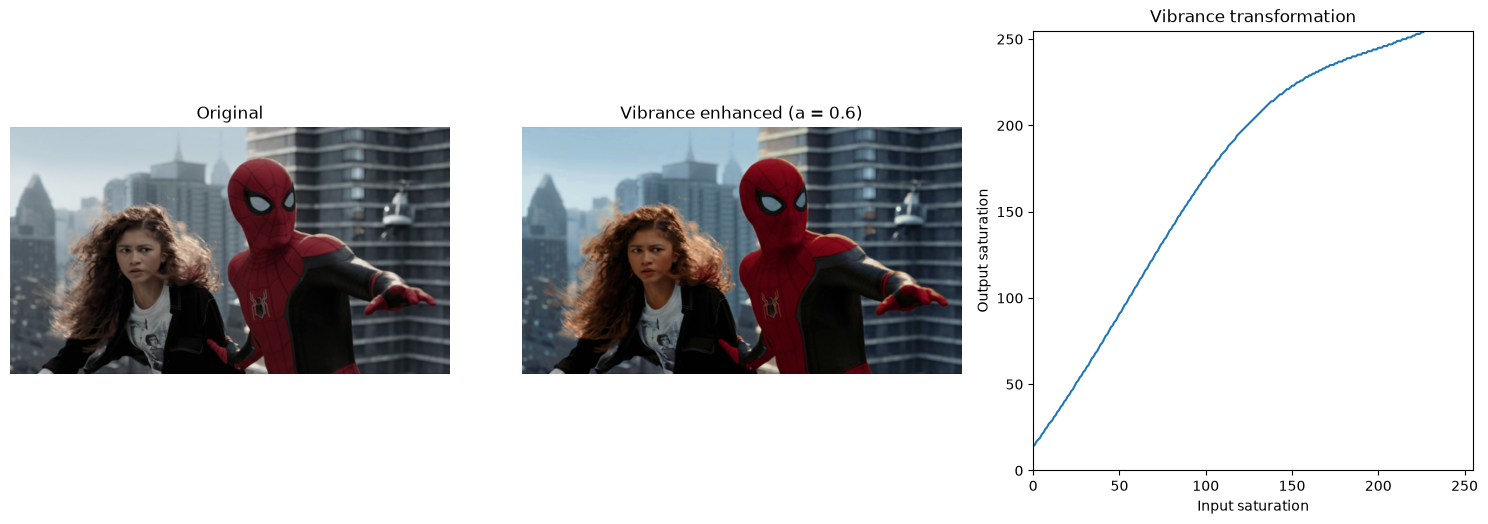

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(cv.cvtColor(img_bgr_vibrant, cv.COLOR_BGR2RGB))
axes[1].set_title(f'Vibrance enhanced (a = {a})')
axes[1].axis('off')

axes[2].plot(lut)
axes[2].set_xlim(0, 255); axes[2].set_ylim(0, 255)
axes[2].set_aspect('equal')
axes[2].set_xlabel('Input saturation')
axes[2].set_ylabel('Output saturation')
axes[2].set_title('Vibrance transformation')

plt.tight_layout()
plt.show()

### Question 5

Function to Histogram Equilization

Max abs difference vs cv.equalizeHist: 0


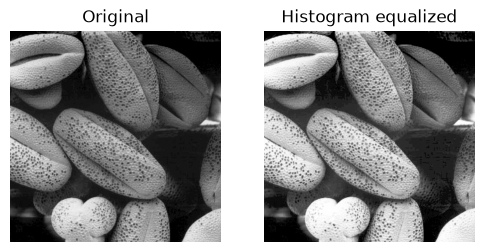

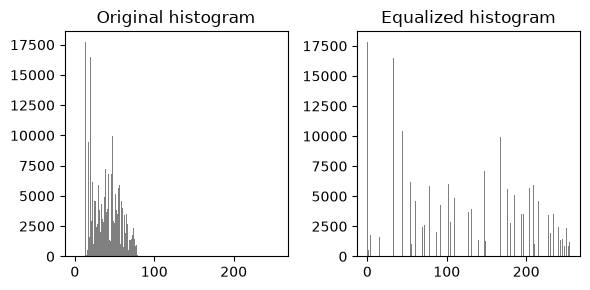

In [158]:
def my_histogram_equalization(img):
    hist = np.bincount(img.ravel(), minlength=256) 
    cdf = np.cumsum(hist)                               
    cdf_min = cdf[cdf > 0].min()                       
    total_pixels = img.size

    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype('uint8')

    equalized = cv.LUT(img, lut)
    return equalized, lut

img_orig = cv.imread('images/q5.tif', cv.IMREAD_GRAYSCALE) 
img_eq, lut = my_histogram_equalization(img_orig)
img_eq_cv = cv.equalizeHist(img_orig)
print("Max abs difference vs cv.equalizeHist:", np.max(np.abs(img_eq.astype(int) - img_eq_cv.astype(int))))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_orig, cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(img_eq, cmap='gray')
axes[1].set_title('Histogram equalized'); axes[1].axis('off')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].hist(img_orig.ravel(), bins=256, range=(0, 255), color='gray')
axes[0].set_title('Original histogram')
axes[1].hist(img_eq.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title('Equalized histogram')
plt.tight_layout()
plt.show()

Original image originally has most of its pixel values concentrated in a narrow, dark range which makes the details hard to see. After equalization, the histogram is spread out more evenly across the full intensity range and the image is more visually pleasing. This has reveales the texture and detail in the image that were not clearly visible before.

### Question 6

#### (a) splitting image into H/S/V, display in grayscale

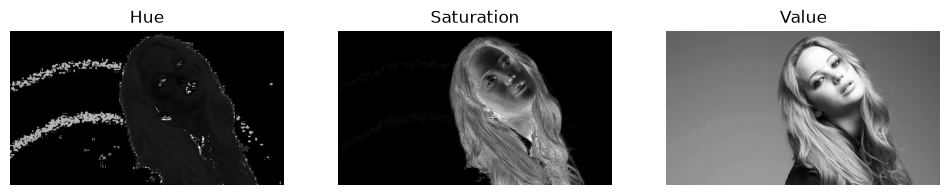

In [160]:
img_bgr = cv.imread('images/q6.jpeg', cv.IMREAD_COLOR)
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
h, s, v = cv.split(img_hsv)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(h, cmap='gray'); axes[0].set_title('Hue'); axes[0].axis('off')
axes[1].imshow(s, cmap='gray'); axes[1].set_title('Saturation'); axes[1].axis('off')
axes[2].imshow(v, cmap='gray'); axes[2].set_title('Value'); axes[2].axis('off')
plt.show()

#### (b) Threshold the right plane to extract the foreground mask

By looking at the 3 planes, we can realize the saturation plane is the ideal plane to extract the foreground mask. 40 was decided as the threshold value after looking at the histogram of the saturation plane.

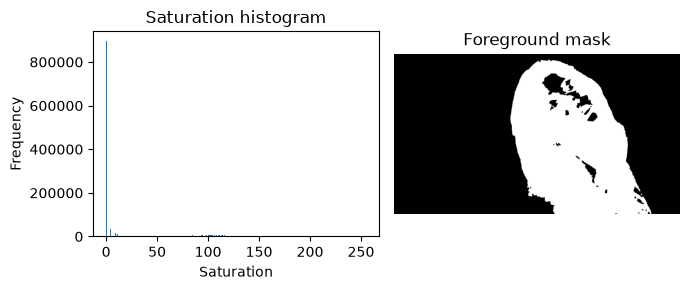

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].hist(s.ravel(), bins=256, range=(0, 255))
axes[0].set_title('Saturation histogram')
axes[0].set_xlabel('Saturation')
axes[0].set_ylabel('Frequency')

axes[1].imshow(mask, cmap='gray')
axes[1].set_title('Foreground mask')
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### (c) Obtaining the foreground only using cv.bitwise_and and computing its histogram

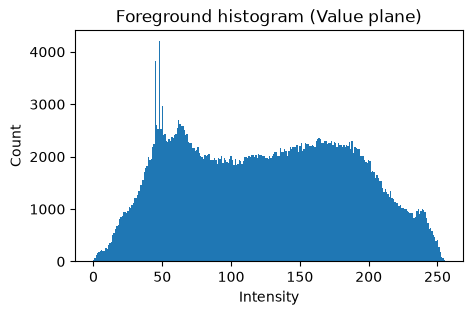

In [169]:
v_foreground = cv.bitwise_and(v, v, mask=mask)

fg_pixels = v_foreground[mask > 0]
hist_fg = np.bincount(fg_pixels, minlength=256)

plt.figure(figsize=(5,3))
plt.bar(np.arange(256), hist_fg, width=1)
plt.title('Foreground histogram (Value plane)')
plt.xlabel('Intensity'); plt.ylabel('Count')
plt.show()

#### (d) Cumulative sum of the histogram using np.cumsum

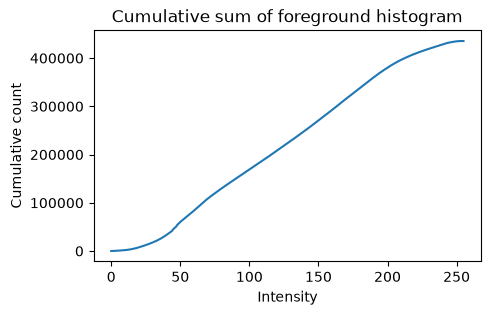

In [170]:
cdf_fg = np.cumsum(hist_fg)

plt.figure(figsize=(5,3))
plt.plot(cdf_fg)
plt.title('Cumulative sum of foreground histogram')
plt.xlabel('Intensity'); plt.ylabel('Cumulative count')
plt.show()

#### (e) Histogram-equalize the foreground

In [ ]:
def my_histogram_equalization(pixels, hist, cdf, out_shape):
    cdf_min = cdf[cdf > 0].min()
    total_pixels = pixels.size
    lut = np.round((cdf - cdf_min) / (total_pixels - cdf_min) * 255)
    lut = np.clip(lut, 0, 255).astype('uint8')
    equalized = lut[pixels]  # apply LUT
    return equalized.reshape(out_shape), lut

fg_eq_values, lut = my_histogram_equalization(fg_pixels, hist_fg, cdf_fg, fg_pixels.shape)
v_fg_equalized = np.zeros_like(v)
v_fg_equalized[mask > 0] = fg_eq_values

#### (f) Extract background, add with the equalized foreground

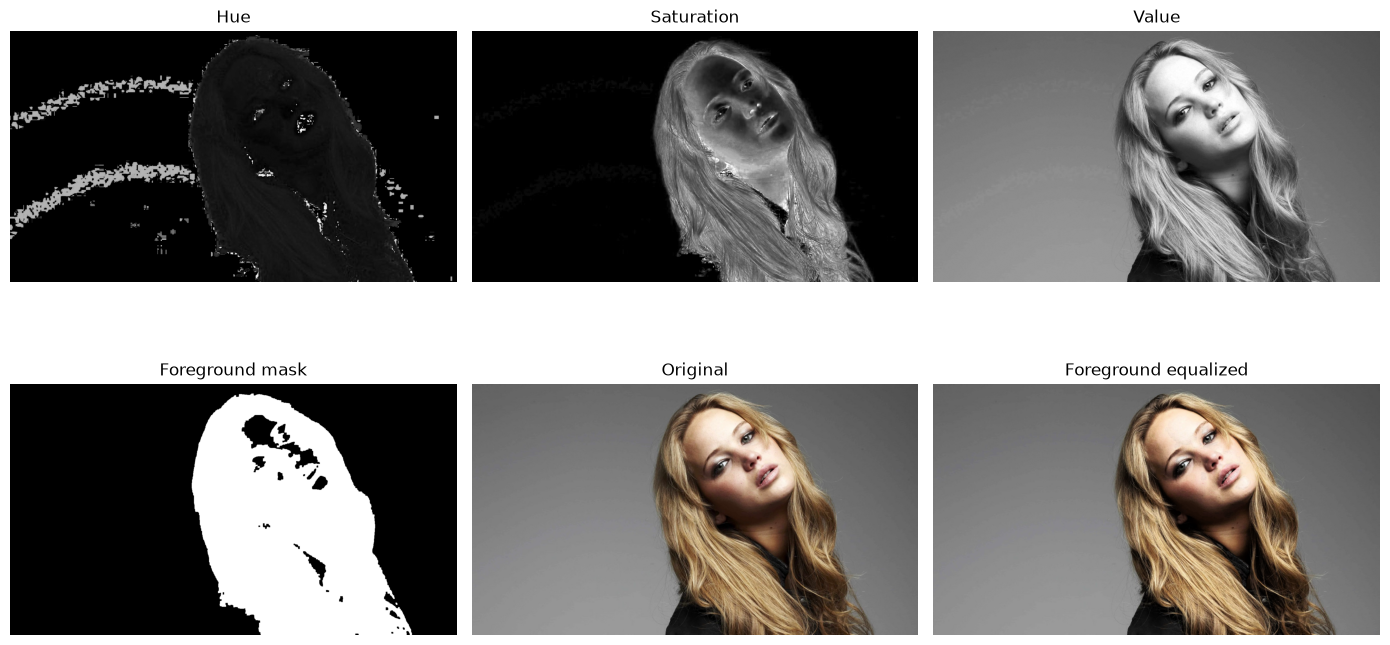

In [173]:
v_background = cv.bitwise_and(v, v, mask=cv.bitwise_not(mask))
v_combined = cv.add(v_background, v_fg_equalized)

img_hsv_result = cv.merge([h, s, v_combined])
img_bgr_result = cv.cvtColor(img_hsv_result, cv.COLOR_HSV2BGR)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes[0,0].imshow(h, cmap='gray'); axes[0,0].set_title('Hue'); axes[0,0].axis('off')
axes[0,1].imshow(s, cmap='gray'); axes[0,1].set_title('Saturation'); axes[0,1].axis('off')
axes[0,2].imshow(v, cmap='gray'); axes[0,2].set_title('Value'); axes[0,2].axis('off')
axes[1,0].imshow(mask, cmap='gray'); axes[1,0].set_title('Foreground mask'); axes[1,0].axis('off')
axes[1,1].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)); axes[1,1].set_title('Original'); axes[1,1].axis('off')
axes[1,2].imshow(cv.cvtColor(img_bgr_result, cv.COLOR_BGR2RGB)); axes[1,2].set_title('Foreground equalized'); axes[1,2].axis('off')
plt.tight_layout()
plt.show()

Here the histogram equilization is only applied to the foreground and the background is left untouched. The saturation plane is seperated into two regions using a threshold. This is useful when only a part of image needs equilization.

### Question 7

#### (a) Using the existing filter2D

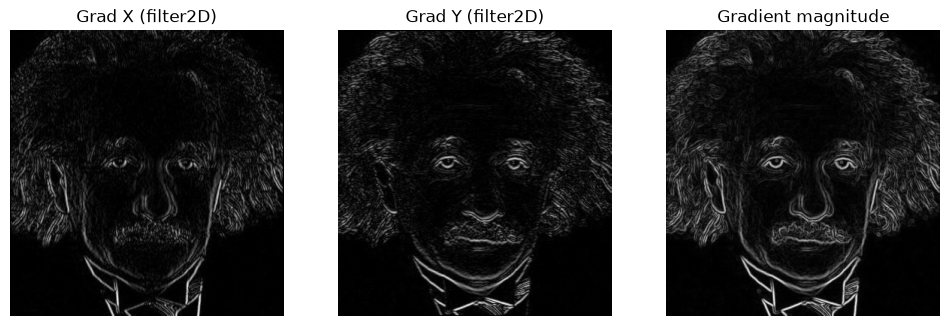

In [ ]:
img_orig = cv.imread('images/q7.jpeg', cv.IMREAD_GRAYSCALE)
img_float = img_orig.astype(np.float64)

sobel_x_kernel = np.array([[1, 0, -1],
                            [2, 0, -2],
                            [1, 0, -1]], dtype=np.float64)

sobel_y_kernel = sobel_x_kernel.T

grad_x_a = cv.filter2D(img_float, -1, sobel_x_kernel)
grad_y_a = cv.filter2D(img_float, -1, sobel_y_kernel)
grad_mag_a = np.sqrt(grad_x_a**2 + grad_y_a**2)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.abs(grad_x_a), cmap='gray'); axes[0].set_title('Grad X (filter2D)'); axes[0].axis('off')
axes[1].imshow(np.abs(grad_y_a), cmap='gray'); axes[1].set_title('Grad Y (filter2D)'); axes[1].axis('off')
axes[2].imshow(grad_mag_a, cmap='gray'); axes[2].set_title('Gradient magnitude'); axes[2].axis('off')
plt.show()

#### (b) Using manual convolution, no OpenCV filtering call

Max abs difference vs filter2D (grad_x): 1484.0


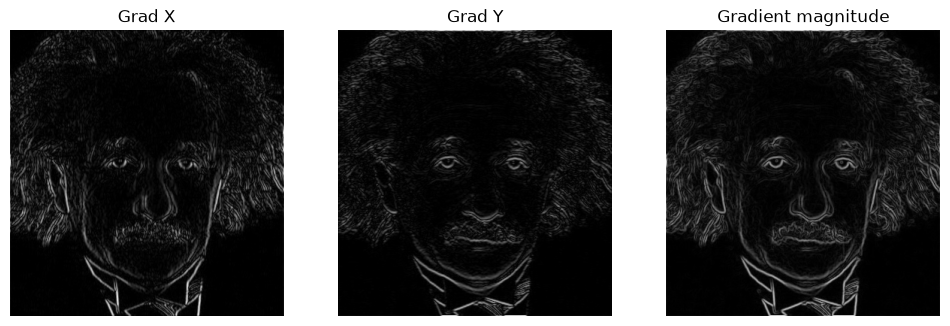

In [174]:
def my_filter2d(img, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    out = np.zeros_like(img, dtype=np.float64)

    kernel_flipped = np.flipud(np.fliplr(kernel))

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            out[i, j] = np.sum(region * kernel_flipped)
    return out

grad_x_b = my_filter2d(img_float, sobel_x_kernel)
grad_y_b = my_filter2d(img_float, sobel_y_kernel)
grad_mag_b = np.sqrt(grad_x_b**2 + grad_y_b**2)

print("Max abs difference vs filter2D (grad_x):", np.max(np.abs(grad_x_a - grad_x_b)))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.abs(grad_x_b), cmap='gray'); axes[0].set_title('Grad X'); axes[0].axis('off')
axes[1].imshow(np.abs(grad_y_b), cmap='gray'); axes[1].set_title('Grad Y'); axes[1].axis('off')
axes[2].imshow(grad_mag_b, cmap='gray'); axes[2].set_title('Gradient magnitude'); axes[2].axis('off')
plt.show()

#### (c) Separable Sobel filtering using the 1D kernel decomposition

Max abs difference vs filter2D (grad_x): 0.0


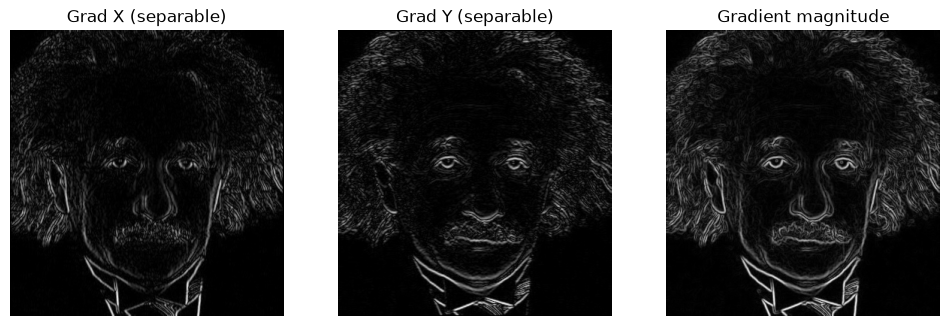

In [ ]:
smooth_kernel = np.array([[1], [2], [1]], dtype=np.float64) 
deriv_kernel  = np.array([[1, 0, -1]], dtype=np.float64)

temp_x = cv.filter2D(img_float, -1, smooth_kernel)
grad_x_c = cv.filter2D(temp_x, -1, deriv_kernel)

temp_y = cv.filter2D(img_float, -1, smooth_kernel.T) 
grad_y_c = cv.filter2D(temp_y, -1, deriv_kernel.T) 

grad_mag_c = np.sqrt(grad_x_c**2 + grad_y_c**2)

print("Max abs difference vs filter2D (grad_x):", np.max(np.abs(grad_x_a - grad_x_c)))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(np.abs(grad_x_c), cmap='gray'); axes[0].set_title('Grad X (separable)'); axes[0].axis('off')
axes[1].imshow(np.abs(grad_y_c), cmap='gray'); axes[1].set_title('Grad Y (separable)'); axes[1].axis('off')
axes[2].imshow(grad_mag_c, cmap='gray'); axes[2].set_title('Gradient magnitude'); axes[2].axis('off')
plt.show()

cv.filter2D, manual convolution function, and the separable 1D kernel decomposition all produce the same gradient results. The gradient in the x-direction highlights vertical edges and the gradient in the y-direction highlights horizontal edges. By using the separable sobel filtering instead of 2D, we can save the computational power.

### Question 8

### (a) Nearest-neighbor zoom

In [175]:
def zoom_nearest_neighbor(img, s):
    h, w = img.shape[:2]
    new_h, new_w = int(round(h * s)), int(round(w * s))

    if img.ndim == 2:
        out = np.zeros((new_h, new_w), dtype=img.dtype)
    else:
        out = np.zeros((new_h, new_w, img.shape[2]), dtype=img.dtype)

    for i in range(new_h):
        for j in range(new_w):
            src_i = min(int(round(i / s)), h - 1)
            src_j = min(int(round(j / s)), w - 1)
            out[i, j] = img[src_i, src_j]

    return out

### (b) Bilinear interpolation zoom

In [176]:
def zoom_bilinear(img, s):
    h, w = img.shape[:2]
    new_h, new_w = int(round(h * s)), int(round(w * s))
    img_f = img.astype(np.float64)

    if img.ndim == 2:
        out = np.zeros((new_h, new_w), dtype=np.float64)
    else:
        out = np.zeros((new_h, new_w, img.shape[2]), dtype=np.float64)

    for i in range(new_h):
        src_y = i / s
        y0 = int(np.floor(src_y))
        y1 = min(y0 + 1, h - 1)
        y0 = min(y0, h - 1)
        wy = src_y - y0

        for j in range(new_w):
            src_x = j / s
            x0 = int(np.floor(src_x))
            x1 = min(x0 + 1, w - 1)
            x0 = min(x0, w - 1)
            wx = src_x - x0

            top = (1 - wx) * img_f[y0, x0] + wx * img_f[y0, x1]
            bottom = (1 - wx) * img_f[y1, x0] + wx * img_f[y1, x1]
            out[i, j] = (1 - wy) * top + wy * bottom

    return np.clip(out, 0, 255).astype('uint8')

Testing: scale up the small images by 4× and compute normalized SSD against the originals

Image 1 — Nearest-neighbor SSD: 255.2957
Image 1 — Bilinear SSD: 200.2451


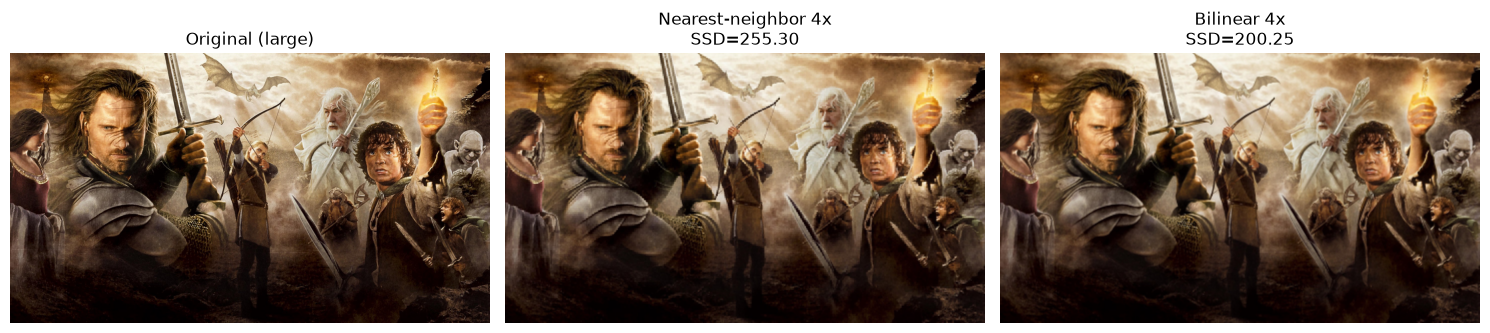

Image 2 — Nearest-neighbor SSD: 64.6294
Image 2 — Bilinear SSD: 48.9607


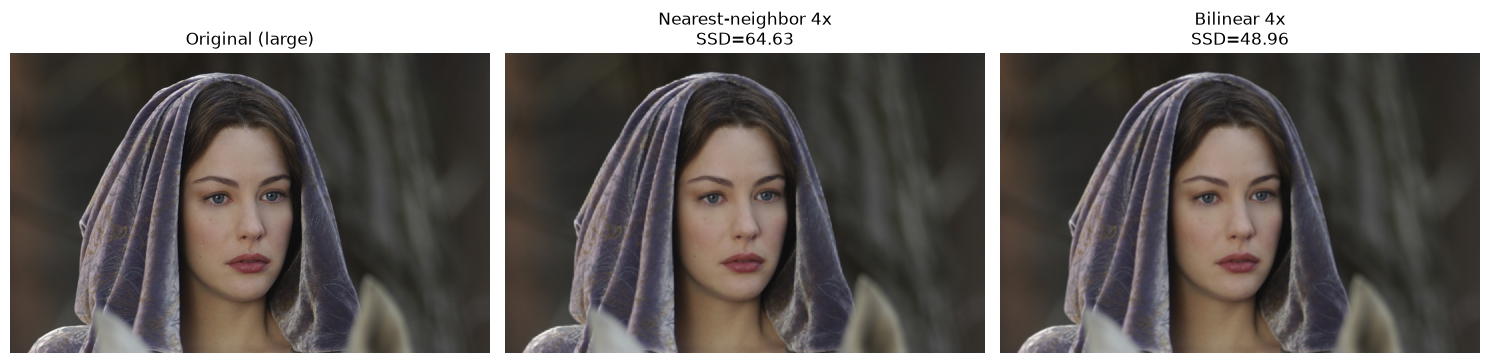

In [ ]:
def normalized_ssd(img1, img2):
    img1_f = img1.astype(np.float64)
    img2_f = img2.astype(np.float64)
    ssd = np.sum((img1_f - img2_f) ** 2)
    return ssd / img1_f.size

orig1 = cv.imread('images/q8(1_large).png', cv.IMREAD_COLOR)
small1 = cv.imread('images/q8(1_small).png', cv.IMREAD_COLOR)
orig2 = cv.imread('images/q8(2_large).png', cv.IMREAD_COLOR)
small2 = cv.imread('images/q8(2_small).png', cv.IMREAD_COLOR)

pairs = [('Image 1', small1, orig1), ('Image 2', small2, orig2)]

for name, small_img, large_img in pairs:
    zoomed_nn = zoom_nearest_neighbor(small_img, 4)
    zoomed_bilin = zoom_bilinear(small_img, 4)

    h, w = large_img.shape[:2]
    zoomed_nn = zoomed_nn[:h, :w]
    zoomed_bilin = zoomed_bilin[:h, :w]

    ssd_nn = normalized_ssd(zoomed_nn, large_img)
    ssd_bilin = normalized_ssd(zoomed_bilin, large_img)

    print(f"{name} — Nearest-neighbor SSD: {ssd_nn:.4f}")
    print(f"{name} — Bilinear SSD: {ssd_bilin:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(cv.cvtColor(large_img, cv.COLOR_BGR2RGB)); axes[0].set_title('Original (large)'); axes[0].axis('off')
    axes[1].imshow(cv.cvtColor(zoomed_nn, cv.COLOR_BGR2RGB)); axes[1].set_title(f'Nearest-neighbor 4x\nSSD={ssd_nn:.2f}'); axes[1].axis('off')
    axes[2].imshow(cv.cvtColor(zoomed_bilin, cv.COLOR_BGR2RGB)); axes[2].set_title(f'Bilinear 4x\nSSD={ssd_bilin:.2f}'); axes[2].axis('off')
    plt.tight_layout()
    plt.show()

The nearest-neighbor method simply copies the closest pixel value from the small image. This is fast but it produces a blocky, pixelated look when the image is scaled up by 4x and especially visible along edges and curves. The bilinear method calculates each new pixel as a weighted average of its four nearest neighbors in the small image. This gives a much smoother and more natural looking result. This difference shows clearly in the normalized SSD values, where bilinear interpolation gives a lower SSD compared to the original large image than nearest-neighbor. This confirms it reconstructs the image more accurately.

### Question 9

#### (a) GrabCut segmentation - mask, foreground, background

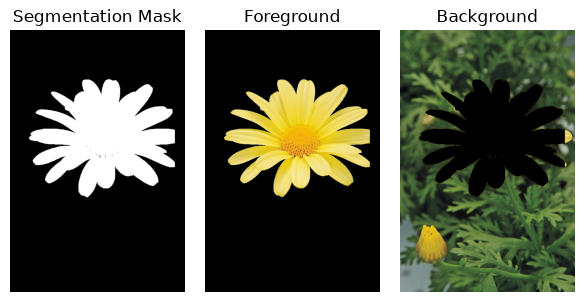

In [184]:
img = cv.cvtColor(cv.imread("images/q9.jpeg"), cv.COLOR_BGR2RGB)

mask = np.zeros(img.shape[:2], np.uint8)
bgd = np.zeros((1, 65), np.float64)
fgd = np.zeros((1, 65), np.float64)

rect = (30, 100, 500, 450)
cv.grabCut(img, mask, rect, bgd, fgd, 5, cv.GC_INIT_WITH_RECT)

mask = np.where((mask == 1) | (mask == 3), 1, 0).astype("uint8")
m = mask[:, :, None]

foreground = img * m
background = img * (1 - m)

plt.figure(figsize=(6, 3))
plt.subplot(1, 3, 1); plt.imshow(mask, cmap="gray"); plt.title("Segmentation Mask"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(foreground); plt.title("Foreground"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(background); plt.title("Background"); plt.axis("off")
plt.tight_layout()
plt.show()

#### (b) Enhanced image with blurred background

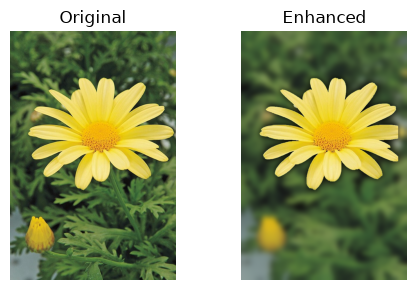

In [186]:
blurred_background = cv.GaussianBlur(background, (61, 61), 0)
blurred_background = blurred_background * (1 - m)
enhanced = foreground + blurred_background

plt.figure(figsize=(5, 3))
plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(enhanced); plt.title("Enhanced"); plt.axis("off")
plt.tight_layout()
plt.show()

#### (c) Why is the background just beyond the edge quite dark?

The​‍​‌‍​‍‌ dark ring becomes visible due to black being background pixels after zeroing out all pixels inside the flower region (img * (1 - m)). So, the flower's area is a pure black before Gaussian blurring. When the Gaussian blur is used to determine the background pixel that it was calculated just after the flower, the kernel window still covers the flower area to some degree so it takes a blend of the artificial black and real background pixels. It lowers the local average, so you get a dark halo around the flower which doesn't have any relation to the original shadow. The most prominent effect is the boundary area because there the largest part of the blur's kernel overcomes the flower part that has been zeroed out. It becomes gradually less evident when the kernel window moves fully outside.

Simply, an effect that comes from blurring a masked image not a shadow of one's own. It will disappear if  the Gaussian blur applied first on the background and only a mask is put ​‍​‌‍​‍‌afterwards.

### Question 10

#### (a) OpenCV's bilateralFilter vs Gaussian blur

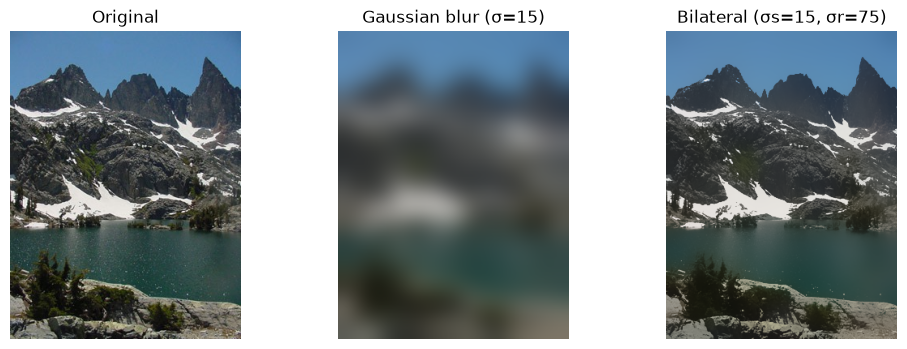

In [195]:
img_bgr = cv.imread('images/q10.jpeg', cv.IMREAD_COLOR)
img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

sigma_s = 15 
sigma_r = 75
d = -1  

bilateral_cv = cv.bilateralFilter(img_bgr, d, sigmaColor=sigma_r, sigmaSpace=sigma_s)

gaussian_blur = cv.GaussianBlur(img_bgr, (0, 0), sigmaX=sigma_s)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_rgb); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(gaussian_blur, cv.COLOR_BGR2RGB)); axes[1].set_title(f'Gaussian blur (σ={sigma_s})'); axes[1].axis('off')
axes[2].imshow(cv.cvtColor(bilateral_cv, cv.COLOR_BGR2RGB)); axes[2].set_title(f'Bilateral (σs={sigma_s}, σr={sigma_r})'); axes[2].axis('off')
plt.show()

The Gaussian blur smooths uniformly in all directions regardless of content, so it blurs across the boundaries between rocks, water, and sky just as much as it smooths flat regions, leaving edges visibly softened. OpenCV's bilateralFilter only averages pixels that are both spatially close and similar in intensity, so it smooths flat areas like the sky and water surface while largely preserving sharp edges such as the mountain ridgeline and rock outlines.

#### (b) Manual bilateral filter vs OpenCV's bilateral filter

In [200]:
def manual_bilateral_filter(img, sigma_s, sigma_r, radius=None):
    if radius is None:
        radius = int(2 * sigma_s)

    img_f = img.astype(np.float64)
    h, w, c = img_f.shape
    padded = np.pad(img_f, ((radius, radius), (radius, radius), (0, 0)), mode='reflect')

    out = np.zeros_like(img_f)
    weight_sum = np.zeros((h, w, 1), dtype=np.float64)

    for dy in range(-radius, radius + 1):
        for dx in range(-radius, radius + 1):
            shifted = padded[radius+dy:radius+dy+h, radius+dx:radius+dx+w, :]

            spatial_w = np.exp(-(dx**2 + dy**2) / (2 * sigma_s**2))
            diff_sq = np.sum((shifted - img_f)**2, axis=2, keepdims=True)
            range_w = np.exp(-diff_sq / (2 * sigma_r**2))

            w_total = spatial_w * range_w
            out += shifted * w_total
            weight_sum += w_total

    out = out / weight_sum
    return np.clip(out, 0, 255).astype('uint8')

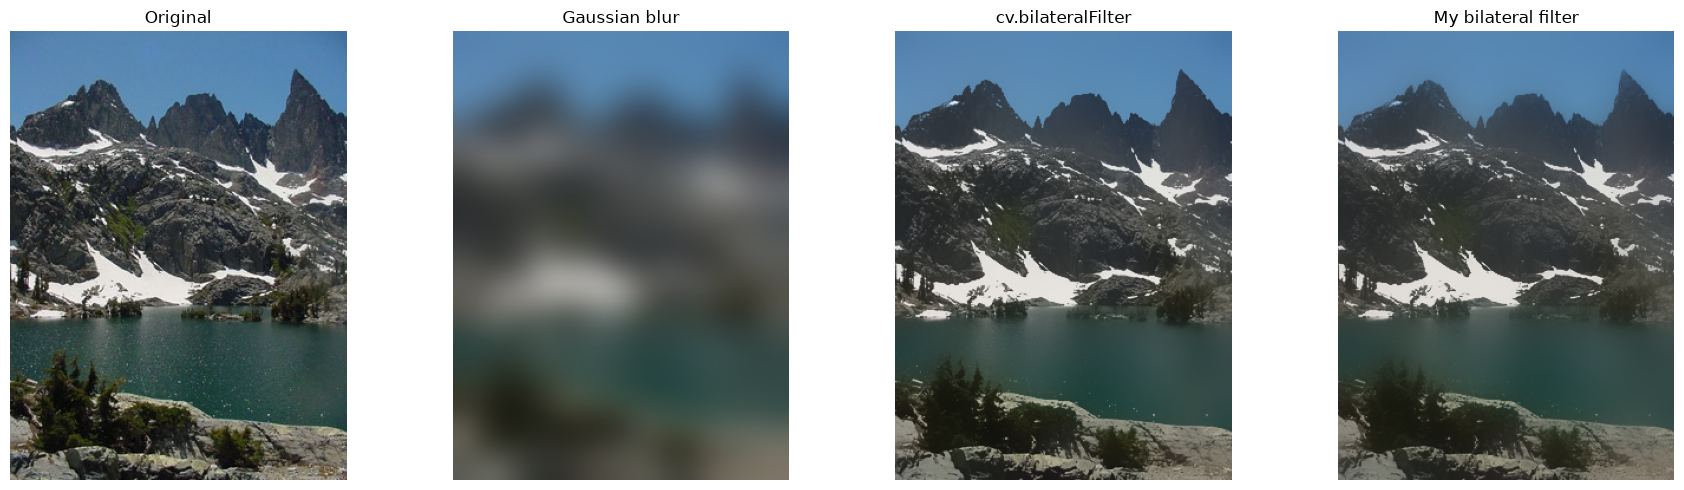

MSE (manual vs cv.bilateralFilter): 50.3242
PSNR (manual vs cv.bilateralFilter): 31.11 dB


In [ ]:
img_bgr = cv.imread('images/q10.jpeg', cv.IMREAD_COLOR) 

sigma_s = 15
sigma_r = 75
d = -1

bilateral_cv = cv.bilateralFilter(img_bgr, d, sigmaColor=sigma_r, sigmaSpace=sigma_s)
gaussian_blur = cv.GaussianBlur(img_bgr, (0, 0), sigmaX=sigma_s)
bilateral_manual = manual_bilateral_filter(img_bgr, sigma_s=sigma_s, sigma_r=sigma_r)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)); axes[0].set_title('Original'); axes[0].axis('off')
axes[1].imshow(cv.cvtColor(gaussian_blur, cv.COLOR_BGR2RGB)); axes[1].set_title('Gaussian blur'); axes[1].axis('off')
axes[2].imshow(cv.cvtColor(bilateral_cv, cv.COLOR_BGR2RGB)); axes[2].set_title('cv.bilateralFilter'); axes[2].axis('off')
axes[3].imshow(cv.cvtColor(bilateral_manual, cv.COLOR_BGR2RGB)); axes[3].set_title('Manual bilateral filter'); axes[3].axis('off')
plt.tight_layout()
plt.show()

diff = bilateral_manual.astype(np.float64) - bilateral_cv.astype(np.float64)
mse = np.mean(diff**2)
psnr = 10 * np.log10((255.0**2) / mse) if mse > 0 else float('inf')

print(f"MSE (manual vs cv.bilateralFilter): {mse:.4f}")
print(f"PSNR (manual vs cv.bilateralFilter): {psnr:.2f} dB")

The two outputs of cv.bilateralfilter and manual bilateralfilter look nearly identical with both smoothing flat regions while keeping the major edges like rocks, tree line, water boundary etc. sharp. The measured MSE between the two is small and the PSNR is high. This indicates images are numerically very close.